In [1]:
exec(open("./funcs/mmj_functions.py").read())

exec(open("./funcs/algo_2_and_3_funcs.py").read())

exec(open("./funcs/algo_4_funcs.py").read()) 


In [2]:
np.random.seed(123)
random.seed(123)

In [3]:
Algorithm_3 = Algorithm_3_Sample_one_path_by_stochastic_greedy


In [4]:
def copy_mmj_distance_no_recursion(distance_matrix, mmj_matrix, i, j, lenX, tempp_dis):
  
    i_list, j_list = [],[]
    for ttt in range(lenX):
        if distance_matrix[i,ttt] < tempp_dis:
            i_list.append(ttt)    
    for kkk in range(lenX):
        if distance_matrix[j,kkk] < tempp_dis:
            j_list.append(kkk)
 
    
    for p in i_list:
        for q in j_list:
            if p != q:
                if mmj_matrix[p,q] == 0:
                    mmj_matrix[p,q] = tempp_dis
                    mmj_matrix[q,p] = tempp_dis
                elif tempp_dis < mmj_matrix[p,q]:
                    mmj_matrix[p,q] = tempp_dis
                    mmj_matrix[q,p] = tempp_dis


def compu_i_j_dist(X, i, j, num_attempts, distance_matrix):
    max_jump_list = [Algorithm_3(X, i, j, distance_matrix) for tt in range(num_attempts)] 
    return np.min(max_jump_list)    


def Algorithm_2(X, num_attempts):
    lenX = len(X)
    distance_matrix = pairwise_distances(X)

    mmj_matrix = np.zeros_like(distance_matrix) 
 
    for i in range(lenX):        
        for j in range(lenX):
            if j > i:
                if mmj_matrix[i,j] > 0:
                    continue
                else:
                    # print(i,j)
                    tempp_dis = compu_i_j_dist(X, i, j, num_attempts, distance_matrix)
                    mmj_matrix[i,j] = tempp_dis
                    mmj_matrix[j,i] = tempp_dis
                    copy_mmj_distance_no_recursion(distance_matrix, mmj_matrix, i, j,lenX, tempp_dis)

    return mmj_matrix

In [5]:
test_data_145 = pickle.load(  open( "./data/test_data_145.p", "rb" ) ) 


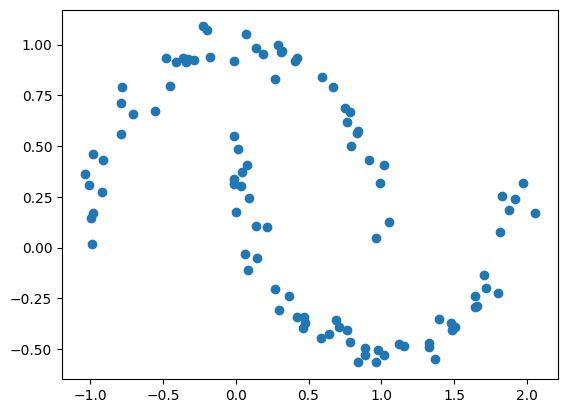

In [6]:
X = test_data_145[3]

    
temmpp = random.sample(range(len(X)), k=100)

X = X[temmpp]
 
plt.scatter(X[:,0],X[:,1])

In [7]:
%%time

MMJ_matrix_algo_1 = cal_mmj_matrix_algo_1_python(X)

CPU times: user 7.73 s, sys: 19.5 ms, total: 7.75 s
Wall time: 7.86 s


In [8]:
%%time

num_attempts = 200

MMJ_matrix_algo_2 = Algorithm_2(X, num_attempts)

CPU times: user 24.7 s, sys: 76.8 ms, total: 24.8 s
Wall time: 25.8 s


In [9]:
%%time

# Calculate MMJ distance matrix with Algorithm 4, implementation and testing of Algorithm 4 see another paper:
# http://www.arxiv.org/abs/2407.07058

MMJ_matrix_algo_4 =  cal_mmj_matrix_by_algo_4_Calculation_and_Copy(X)


CPU times: user 11.4 ms, sys: 1.8 ms, total: 13.2 ms
Wall time: 26.1 ms


In [10]:
np.round(MMJ_matrix_algo_1,3)

array([[0.   , 0.368, 0.238, ..., 0.081, 0.168, 0.368],
       [0.368, 0.   , 0.368, ..., 0.368, 0.368, 0.197],
       [0.238, 0.368, 0.   , ..., 0.238, 0.238, 0.368],
       ...,
       [0.081, 0.368, 0.238, ..., 0.   , 0.168, 0.368],
       [0.168, 0.368, 0.238, ..., 0.168, 0.   , 0.368],
       [0.368, 0.197, 0.368, ..., 0.368, 0.368, 0.   ]])

In [11]:
np.round(MMJ_matrix_algo_2,3)

array([[0.   , 0.368, 0.238, ..., 0.081, 0.168, 0.368],
       [0.368, 0.   , 0.398, ..., 0.368, 0.368, 0.301],
       [0.238, 0.398, 0.   , ..., 0.238, 0.238, 0.368],
       ...,
       [0.081, 0.368, 0.238, ..., 0.   , 0.168, 0.368],
       [0.168, 0.368, 0.238, ..., 0.168, 0.   , 0.368],
       [0.368, 0.301, 0.368, ..., 0.368, 0.368, 0.   ]])

In [12]:
np.allclose(MMJ_matrix_algo_1, MMJ_matrix_algo_2)

False

In [13]:
np.sum(np.abs(MMJ_matrix_algo_1 - MMJ_matrix_algo_2))

60.624210188527954

In [14]:
np.allclose(MMJ_matrix_algo_1, MMJ_matrix_algo_4)

True

In [15]:
# Note the result of Algorithm 2 is inaccurate, 
# because the result of Algorithm 2 is supposed to be an estimation of the MMJ matrix.


In [16]:
# Also note the code implementation of Algorithm 2 is slightly different 
# from the pseudo code in the paper, I have not got a good method for copying the values recursively.
